In [1]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import WhitespaceTokenizer
from nltk import pos_tag
from nltk.corpus import wordnet
import nltk

nltk.download('omw-1.4')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\andre\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\andre\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\andre\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\andre\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

### Sources:

*   [GloVe Embedding article](https://medium.com/analytics-vidhya/basics-of-using-pre-trained-glove-vectors-in-python-d38905f356db)
*    [Emojis - source1](https://towardsdatascience.com/emojis-aid-social-media-sentiment-analysis-stop-cleaning-them-out-bb32a1e5fc8e)
*   [Emojis - source2](https://medium.com/@HeCanThink/emoji-lets-deal-with-in-python-dcc88b1f8ab1)
*   [Emojis - source3](https://kt.ijs.si/data/Emoji_sentiment_ranking/)
*   [Spell checker - source 1](https://www.johnsnowlabs.com/easily-correcting-typos-and-spelling-errors-on-texts-with-spark-nlp-and-python/)
*   [Spell checker - source 2](https://stackoverflow.com/questions/69851442/q-python-spell-checker-using-nltk)
*   [Lemmatization with a pretrained model - Spark NLP](https://sparknlp.org/2021/11/22/lemma_antbnc_en.html)

In [2]:
import pandas as pd
import gensim
import emoji
import nltk
import torch
import sys
import shutil
import urllib
import tarfile
from pathlib import Path
import numpy as np
from typing import Iterable
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import gensim.downloader as gloader
from autocorrect import Speller
import os

import pandas as pd
import gensim
import gensim.downloader as gloader
from typing import List, Callable, Dict
from collections import OrderedDict
import matplotlib.pyplot as plt
import umap
from tqdm import tqdm
import numpy as np

import re

## hashtags segmenter: https://github.com/grantjenks/python-wordsegment
import wordsegment as ws 
ws.load()

## mention and lemmatization
import spacy
nlp = spacy.load("en_core_web_sm")

LEMMATIZED_TRAIN_DATA_FILE = "training_data_lemm.csv"

c:\Users\andre\Desktop\AlmaMater\NLP\Assignment\Assignment 1\.venv\Lib\site-packages\spacy\util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.8.0) was trained with spaCy v3.8.0 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


In [3]:
# choose right device
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device("mps")
print('Torch Device: %s' % device)

Torch Device: cpu


# Data Visualization
Download data, Load Json in Pandas dataframes, Generate Hard Labels, Filter English, Filter columns, Encode Hard Label in 0-1

# Data Cleaning

In [4]:
GOOD_SYMBOLS_RE = re.compile('[^0-9a-z <>]')
re.sub(GOOD_SYMBOLS_RE," ", "cica34^ ^34+ <rt> +++44")

'cica34   34  <rt>    44'

In [5]:
## REGEXs
GOOD_SYMBOLS_RE = re.compile('[^0-9a-z +_<>]')
HASHTAG_REGEX = re.compile('#\w+')
MENTION_REGEX = re.compile("@\w+")
URL_REGEX = re.compile('https?://(?:www\.)?[\w-]+\.[\w/._-]+')
## SPECIAL TOKENs
TOKEN_LESSER_THAN = " <LESSER_THAN> "
TOKEN_GREATER_THAN = " <GREATER_THAN> "
TOKEN_LEFT_SINGLE_QUOTE = " <LEFT_SINGLE_QUOTE> "
TOKEN_RIGHT_SINGLE_QUOTE = " <RIGHT_SINGLE_QUOTE> "
TOKEN_LEFT_DOUBLE_QUOTE = " <LEFT_DOUBLE_QUOTE> "
TOKEN_RIGHT_DOUBLE_QUOTE = " <RIGHT_DOUBLE_QUOTE> "
TOKEN_ELLIPSIS = " <ELLIPSIS> "
TOKEN_LESSER_THAN = " <LESSER_THAN> "
TOKEN_LESSER_THAN = " <LESSER_THAN> "
TOKEN_URL = " <URL> "
TOKEN_HASHTAG_START = " <HASHTAG_START> "
TOKEN_HASHTAG_END = " <HASHTAG_END> "

try:
    STOPWORDS = set(stopwords.words('english'))
except LookupError:
    nltk.download('stopwords')
    STOPWORDS = set(stopwords.words('english'))

In [6]:
def lower(text):
    return text.lower()

def strip_text(text):
    return text.strip()

def contains_emoji(text):
    return any(emoji.is_emoji(char) for char in text)

def contains_mention(text):
    return re.findall(MENTION_REGEX, text)

def replace_urls_with_token(text):
    return re.sub(URL_REGEX, TOKEN_URL, text)

def remove_angle_brackets(text):
    text.replace("&amp", " and ")
    text.replace("<", TOKEN_LESSER_THAN)
    text.replace(">", TOKEN_GREATER_THAN)
    return text

def emoji2description(text):
    return emoji.replace_emoji(text, replace=lambda chars, data_dict: ' '.join(data_dict['en'].split('_')).strip(':')+' ')

def encode_data_with_function(data, encoding, column = 'tweet'):
    data[column] = data[column].apply(encoding)
    return data

def replace_quote_symbols(text):
    text = text.replace("‘", TOKEN_LEFT_SINGLE_QUOTE)
    text = text.replace("’", TOKEN_RIGHT_SINGLE_QUOTE)
    text = text.replace("“", TOKEN_LEFT_DOUBLE_QUOTE)
    text = text.replace("”", TOKEN_RIGHT_DOUBLE_QUOTE)
    text = text.replace("\"", TOKEN_LEFT_DOUBLE_QUOTE)
    text = text.replace("\"", TOKEN_RIGHT_DOUBLE_QUOTE)
    text = text.replace("...", TOKEN_ELLIPSIS)
    return text

def replace_mention(text):
    mention = re.findall(MENTION_REGEX, text)
    if mention:
        new_sen = text
        for m in mention:
            doc = nlp(m)
            sub = [c.label_ for c in doc.ents]
            if sub:
                new_sen = new_sen.replace(m, f"<{sub[0]}>")
            else:
                new_sen = new_sen.replace(m, f"<{[c.pos_ for c in doc][0]}>")
        return new_sen
    else:
        return text    
    
def replace_hashtag(text):
    """
    Replaces hashtags, by segmenting hashtags and adding special tokens in front and at the end of it.
    """
    def segment(x) :
        return TOKEN_HASHTAG_START+' '.join(ws.segment(x))+TOKEN_HASHTAG_END
    return re.sub(HASHTAG_REGEX, lambda x: segment(x.group(0)), text)


# def replace_special_characters(text: str) -> str:
#     """
#     Replaces special characters, such as paranthesis, with spacing character
#     """
#     return REPLACE_BY_SPACE_RE.sub(' ', text)

def replace_br(text: str) -> str:
    """
    Replaces br characters
    """
    return text.replace('br', '')

def filter_out_uncommon_symbols(text: str) -> str:
    """
    Removes any special character that is not in the good symbols list (check regular expression)
    """
    return GOOD_SYMBOLS_RE.sub(' ', text)

def remove_stopwords(text: str) -> str:
    return ' '.join([x for x in text.split() if x and x not in STOPWORDS])

def strip_text(text: str) -> str:
    """
    Removes any left or right spacing (including carriage return) from text.
    """
    return text.strip()

In [7]:
def majority_vote(lst):
    count = Counter(lst)
    return 1 if count.most_common(1)[0][0] == "YES" else 0

def yes_probability(lst):
    # Count the number of YES and NO votes
    yes_count = lst.count("YES")
    no_count = lst.count("NO")
    
    # Calculate the probability of YES
    total = yes_count + no_count
    if total == 0:
        return None  # To handle cases where there are no "YES" or "NO" votes in the list
    else:
        return yes_count / total

def generate_labels_task1(data):
    data = data.drop(['annotators','number_annotators','gender_annotators','age_annotators','labels_task2','labels_task3'],axis=1)
    data['hard_label_task1'] = data['labels_task1'].apply(majority_vote)
    data['soft_label_task1'] = data['labels_task1'].apply(yes_probability)
    return data

def load_and_preprocess_dataset(file_path):
    data = pd.read_json(file_path).T
    data = generate_labels_task1(data)
    data['original'] = data['tweet'] #to remove
    columns_to_keep = ['id_EXIST','lang','tweet', 'hard_label_task1','soft_label_task1', 'original']
    data = data[columns_to_keep]
    data = filter_english_only(data)
    data = encode_data_with_function(data,remove_angle_brackets)
    data = encode_data_with_function(data,emoji2description)
    data = encode_data_with_function(data,replace_mention)
    data = encode_data_with_function(data,replace_hashtag)
    data = encode_data_with_function(data,replace_urls_with_token) 
    data = encode_data_with_function(data,replace_quote_symbols)
    # data = encode_data_with_function(data,replace_special_characters)
    data = encode_data_with_function(data,filter_out_uncommon_symbols)
    #data = encode_data_with_function(data,replace_br)
    data = encode_data_with_function(data,remove_stopwords)
    data = encode_data_with_function(data,lower)
    data = encode_data_with_function(data,strip_text)
    return data

def load_and_preprocess_dataset1(file_path, index_to_print):
    # Load and transpose the data
    data = pd.read_json(file_path).T
    print(f"Initial Data (index == {index_to_print}):\n", data.loc[index_to_print] if index_to_print in data.index else "Index not found")
    
    # Generate labels for task 1
    data = generate_labels_task1(data)
    print(f"After generate_labels_task1 (index == {index_to_print}):\n", data.loc[index_to_print] if index_to_print in data.index else "Index not found")
    
    # Add 'original' column (to remove)
    data['original'] = data['tweet']
    
    # Keep only necessary columns
    columns_to_keep = ['id_EXIST', 'lang', 'tweet', 'hard_label_task1', 'soft_label_task1', 'original']
    data = data[columns_to_keep]
    print(f"After keeping specific columns (index == {index_to_print}):\n", data.loc[index_to_print] if index_to_print in data.index else "Index not found")
    
    # Filter for English-only data
    data = filter_english_only(data)
    print(f"After filter_english_only (index == {index_to_print}):\n", data.loc[index_to_print] if index_to_print in data.index else "Index not found")
    
    # Apply each encoding function and print the result
    encoding_functions = [
        remove_angle_brackets, 
        emoji2description, 
        replace_mention, 
        replace_hashtag,
        replace_urls_with_token, 
        replace_quote_symbols, 
        # replace_special_characters,
        lower, 
        filter_out_uncommon_symbols, 
        remove_stopwords, 
        strip_text
    ]
    
    for func in encoding_functions:
        data = encode_data_with_function(data, func)
        print(f"After {func.__name__} (index == {index_to_print}):\n", data.loc[index_to_print]['tweet'] if index_to_print in data.index else "Index not found")
    
    return data


def filter_english_only(df):
    new_df = df[df['lang'].astype('str').str.contains('en')]
    return new_df


In [8]:
load_and_preprocess_dataset1("data/training.json", 200898)

Initial Data (index == 200898):
 id_EXIST                                                        200898
lang                                                                en
tweet                @carwu1 to achieve equality between districts ...
number_annotators                                                    6
annotators           [Annotator_467, Annotator_468, Annotator_469, ...
gender_annotators                                   [F, F, M, M, M, F]
age_annotators                  [18-22, 23-45, 18-22, 23-45, 46+, 46+]
labels_task1                                  [NO, NO, NO, NO, NO, NO]
labels_task2                                        [-, -, -, -, -, -]
labels_task3                            [[-], [-], [-], [-], [-], [-]]
split                                                         TRAIN_EN
Name: 200898, dtype: object
After generate_labels_task1 (index == 200898):
 id_EXIST                                                       200898
lang                                    

,id_EXIST,lang,tweet,hard_label_task1,soft_label_task1,original
200001,200001,en,ffs laying blame bastard murdered novel idea k...,1,0.500000,FFS! How about laying the blame on the bastard...
200002,200002,en,writing uni essay local pub coffee random old ...,1,0.833333,Writing a uni essay in my local pub with a cof...
200003,200003,en,<noun> 2021 1921 dont appreciate two rides tea...,1,0.666667,@UniversalORL it is 2021 not 1921. I dont appr...
200004,200004,en,<org> unacceptable use title men interviewed f...,1,0.500000,@GMB this is unacceptable. Use her title as yo...
200005,200005,en,<left_single_quote> making harder target <righ...,1,0.500000,‘Making yourself a harder target’ basically bo...
...,...,...,...,...,...,...
203256,203256,en,idk <right_single_quote> bitches think half as...,1,1.000000,idk why y’all bitches think having half your a...
203257,203257,en,part experiment <org> learning though little b...,1,1.000000,This has been a part of an experiment with @Wo...
203258,203258,en,<left_double_quote> take already <left_double_...,1,0.666667,"""Take me already"" ""Not yet. You gotta be ready..."
203259,203259,en,<person> look like whore lh <url>,1,1.000000,@clintneedcoffee why do you look like a whore?...


In [9]:
training_data = load_and_preprocess_dataset("data/training.json")
print('Finished training')
validation_data = load_and_preprocess_dataset("data/validation.json")
print('Finished validation')
test_data = load_and_preprocess_dataset("data/test.json")
print('Finished test')

Finished training
Finished validation
Finished test


In [10]:
print(training_data.shape)
print(validation_data.shape)
print(test_data.shape)

print(training_data.columns)


(3260, 6)
(177, 6)
(312, 6)
Index(['id_EXIST', 'lang', 'tweet', 'hard_label_task1', 'soft_label_task1',
       'original'],
      dtype='object')


In [11]:
display(training_data.head())

,id_EXIST,lang,tweet,hard_label_task1,soft_label_task1,original
200001,200001,en,ow laying blame bastard murdered ovel idea kno...,1,0.500000,FFS! How about laying the blame on the bastard...
200002,200002,en,riting uni essay local pub coffee andom old ma...,1,0.833333,Writing a uni essay in my local pub with a cof...
200003,200003,en,< > 2021 1921 dont appreciate two rides team m...,1,0.666667,@UniversalORL it is 2021 not 1921. I dont appr...
200004,200004,en,< > unacceptable se title men interviewed fact...,1,0.500000,@GMB this is unacceptable. Use her title as yo...
200005,200005,en,< _ _ > aking harder target < _ _ > basically ...,1,0.500000,‘Making yourself a harder target’ basically bo...


In [12]:
display(test_data.head())

,id_EXIST,lang,tweet,hard_label_task1,soft_label_task1,original
400178,400178,en,1st day pool beautiful unday oo bad dared go d...,0,0.000000,1st day at the pool on a beautiful Sunday in N...
400179,400179,en,< _ _ > like outfit except dress frigid bitch ...,1,0.833333,“I like your outfit too except when i dress up...
400180,400180,en,< > pleading face sparkling heart though angst...,0,0.000000,"@KNasFanFic 🥺💖 same, though!!! the angst just ..."
400181,400181,en,< > < > uck cunt ried vote multiple times,1,0.833333,@themaxburns @GOP Fuck that cunt. Tried to vot...
400182,400182,en,< > u gotta say shit like < _ _ > < _ _ > fuck...,1,1.000000,@ultshunnie u gotta say some shit like “i’ll f...


In [13]:
target = "hard_label_task1"

In [14]:
training_data[target].value_counts()

hard_label_task1
0    1941
1    1319
Name: count, dtype: int64

Train '0:1' score ratio --> 1.47 : 1
Test  '0:1' score ratio --> 1.21 : 1


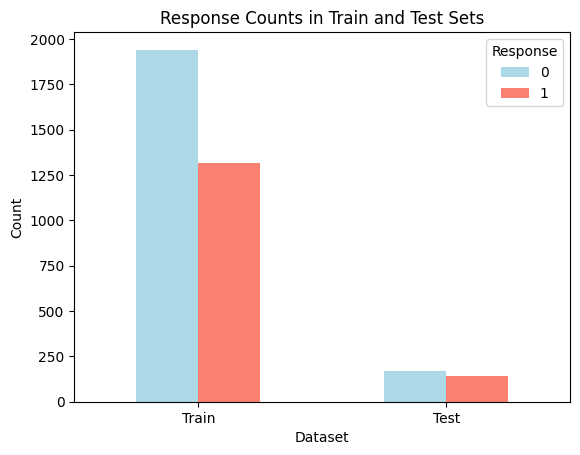

In [15]:
train_counts = training_data[target].value_counts()
test_counts = test_data[target].value_counts()

# Combine counts into a single DataFrame for plotting
counts_df = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
}).T  # Transpose to have "yes" and "no" as columns

print(f"Train '0:1' score ratio --> {counts_df[0]['Train']/counts_df[1]['Train']:.2f} : 1")
print(f"Test  '0:1' score ratio --> {counts_df[0]['Test']/counts_df[1]['Test']:.2f} : 1")

# Plotting
counts_df.plot(kind='bar', color=['lightblue', 'salmon'])
plt.title('Response Counts in Train and Test Sets')
plt.xlabel('Dataset')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Response')
plt.show()

## Lemmatization - Same as Tutorial 1

In [16]:

# def lemmatize_sentences(sentences):
#     lemmatized_sentences = []
#     for sen in sentences:
#         doc = nlp(sen)
#         lemmatized_sentence = " ".join([token.lemma_ for token in doc])
#         lemmatized_sentences.append(lemmatized_sentence)
#     return np.array(lemmatized_sentences)

In [17]:
def get_wordnet_key(pos_tag):
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:          
        return 'n'

def lem_text(text, lemmatizer = WordNetLemmatizer(), tokenizer = WhitespaceTokenizer(), spell_checker=True, spell=Speller(lang='en')):
    _text = []
    for t in text.split(" "):
        _text += [t if "<" in t else ' '.join(ws.segment(t))]
    text = ' '.join(_text)
    tokens = tokenizer.tokenize(text)

    if spell_checker:
      tokens = [spell(w) for w in tokens]
    tagged = pos_tag(tokens)
    words = [lemmatizer.lemmatize(word, get_wordnet_key(tag)) for word, tag in tagged]
    return " ".join(words)

In [18]:
if not os.path.isfile(LEMMATIZED_TRAIN_DATA_FILE):
    training_data = encode_data_with_function(training_data,lem_text)
    training_data.to_csv(LEMMATIZED_TRAIN_DATA_FILE)
else:
    training_data = pd.read_csv(LEMMATIZED_TRAIN_DATA_FILE)

# Example
# sentences = ["Cats are running.", "JAHA was cooking some potatoes"]
# #clean_lemmas = lemmatize_sentences(sentences)
# #print(clean_lemmas)
# for sentence in sentences:
#     print(lem_text(sentence))

# Text encoding

In [19]:
# with open("C:/Users/andre/Desktop/AlmaMater/NLP/Assignment/Assignment 1/NLP_AssignmentOne/glove.twitter.27B.100d.txt", 'r', encoding="utf-8") as f:
#     for line in f:
#         values = line.split()
#         word = values[0]
#         vector = np.asarray(values[1:], "float32")
#         embeddings_dict[word] = vector

In [20]:
def load_embedding_model(model_type: str,
                         embedding_dimension: int = 50) -> gensim.models.keyedvectors.KeyedVectors:
    """
    Loads a pre-trained word embedding model via gensim library.

    :param model_type: name of the word embedding model to load.
    :param embedding_dimension: size of the embedding space to consider

    :return
        - pre-trained word embedding model (gensim KeyedVectors object)
    """
    download_path = ""
    if model_type.strip().lower() == 'word2vec':
        download_path = "word2vec-google-news-300"

    elif model_type.strip().lower() == 'glove':
        download_path = "glove-wiki-gigaword-{}".format(embedding_dimension)
    elif model_type.strip().lower() == 'fasttext':
        download_path = "fasttext-wiki-news-subwords-300"
    else:
        raise AttributeError("Unsupported embedding model type! Available ones: word2vec, glove, fasttext")
        
    try:
        emb_model = gloader.load(download_path)
    except ValueError as e:
        print("Invalid embedding model name! Check the embedding dimension:")
        print("Word2Vec: 300")
        print("Glove: 50, 100, 200, 300")
        print('FastText: 300')
        raise e

    return emb_model

In [21]:
embedding_model = load_embedding_model(model_type="glove",
                                       embedding_dimension=200)

In [22]:
def build_vocabulary(df: pd.DataFrame) -> (Dict[int, str], Dict[str, int], List[str]):
    """
    Given a dataset, builds the corresponding word vocabulary.

    :param df: dataset from which we want to build the word vocabulary (pandas.DataFrame)
    :return:
      - word vocabulary: vocabulary index to word
      - inverse word vocabulary: word to vocabulary index
      - word listing: set of unique terms that build up the vocabulary
    """
    idx_to_word = OrderedDict()
    word_to_idx = OrderedDict()
    
    curr_idx = 0
    for sentence in tqdm(df['tweet'].values):
        tokens = sentence.split()
        for token in tokens:
            if token not in word_to_idx:
                word_to_idx[token] = curr_idx
                idx_to_word[curr_idx] = token
                curr_idx += 1

    word_listing = list(idx_to_word.values())
    return idx_to_word, word_to_idx, word_listing

In [23]:
idx_to_word, word_to_idx, word_listing = build_vocabulary(training_data)
print(f'[Debug] Index -> Word vocabulary size: {len(idx_to_word)}')
print(f'[Debug] Word -> Index vocabulary size: {len(word_to_idx)}')
print(f'[Debug] Some words: {[(idx_to_word[idx], idx) for idx in np.arange(10) + 1]}')

100%|██████████| 3260/3260 [00:00<00:00, 196305.04it/s]

[Debug] Index -> Word vocabulary size: 8249
[Debug] Word -> Index vocabulary size: 8249
[Debug] Some words: [('lay', 1), ('blame', 2), ('bastard', 3), ('murder', 4), ('o', 5), ('vel', 6), ('idea', 7), ('know', 8), ('<', 9), ('write', 10)]


In [24]:
def evaluate_vocabulary(idx_to_word: Dict[int, str], word_to_idx: Dict[str, int],
                        word_listing: List[str], df: pd.DataFrame, check_default_size: bool = False):
    print("[Vocabulary Evaluation] Size checking...")
    assert len(idx_to_word) == len(word_to_idx)
    assert len(idx_to_word) == len(word_listing)

    print("[Vocabulary Evaluation] Content checking...")
    for i in tqdm(range(0, len(idx_to_word))):
        assert idx_to_word[i] in word_to_idx
        assert word_to_idx[idx_to_word[i]] == i

    print("[Vocabulary Evaluation] Consistency checking...")
    _, _, first_word_listing = build_vocabulary(df)
    _, _, second_word_listing = build_vocabulary(df)
    assert first_word_listing == second_word_listing

    print("[Vocabulary Evaluation] Toy example checking...")
    toy_df = pd.DataFrame.from_dict({
        'tweet': ["all that glitters is not gold", "all in all i like this assignment"]
    })
    _, _, toy_word_listing = build_vocabulary(toy_df)
    toy_valid_vocabulary = set(' '.join(toy_df['tweet'].values).split())
    assert set(toy_word_listing) == toy_valid_vocabulary

In [25]:
print("Vocabulary evaluation...")
evaluate_vocabulary(idx_to_word, word_to_idx, word_listing, training_data)
print("Evaluation completed!")

Vocabulary evaluation...
[Vocabulary Evaluation] Size checking...
[Vocabulary Evaluation] Content checking...


100%|██████████| 8249/8249 [00:00<00:00, 6305597.54it/s]


[Vocabulary Evaluation] Consistency checking...


100%|██████████| 3260/3260 [00:00<00:00, 217397.47it/s]


[Vocabulary Evaluation] Toy example checking...


100%|██████████| 2/2 [00:00<?, ?it/s]

Evaluation completed!


In [26]:
def check_OOV_terms(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                    word_listing):
    """
    Checks differences between pre-trained embedding model vocabulary
    and dataset specific vocabulary in order to highlight out-of-vocabulary terms.

    :param embedding_model: pre-trained word embedding model (gensim wrapper)
    :param word_listing: dataset specific vocabulary (list)

    :return
        - list of OOV terms
    """
    embedding_vocabulary = set(embedding_model.key_to_index.keys())
    oov = set(word_listing).difference(embedding_vocabulary)
    return list(oov)

In [27]:
oov_terms = check_OOV_terms(embedding_model, word_listing)
oov_percentage = float(len(oov_terms)) * 100 / len(word_listing)
print(f"Total OOV terms: {len(oov_terms)} ({oov_percentage:.2f}%)")

Total OOV terms: 204 (2.47%)


In [28]:
print(oov_terms)

['milie', '42yrs', 'ndia', 'ssr2021', 'r62a7', 'yyyy', 'paperswritingpro<', 'itsnotacomplimentmelbourne<', 'nabla', 'usopen2021', '1yrs', 'look<', 'dumbasses', '25inchface', 'keep1e', 'acephalous', 'schwanzlutschen', 'romanize', 'kovi', 'id2022', 'oman4', 'ie0o', '2her', 'cken', '30yo', 'br<', 'ins<', 'lice3', 'cornix', 'canada1111', 'p01', 'mdy', '4gunshot', 'cachonda', 'skie', 'prop47', 'ao3', 'nter', 'xl8', 'knotless', 'weightlift', 'ikk', 'munic', 'unfahrifhdyfhdh', 'nutjob', 'day2022', 'hne', '1<', 'hooool', 'changemakers', '65k', 'bebsvsbbxhdhshxbf', 'fall2021', 'swachhsurvekshan2022', 'bullcrap', 'yoga4', 'dition', 'cker', 'uge', 'wh0r3s', 'orita', 'fancruft', '100horrormoviesin92', '2018<', 'ohio7', 'day2021', 'ditions', 'dmy', 'futanari', 'beyondblue', 'tf2', 'out2021', '4get', 'dwgs', '000s', 'gangbanged', 'wh1t3', 'daille', 'age10', 'monday2021', 'ghits', '8yrs', 'tique', 'giment', 'transcluded', 'catcall', 'b9aw', 'ricas', 'crossdresser', 'religion0n', 'ller', 'akdhajhdajja

In [29]:
tmp = [u for u in oov_terms if '<' not in u]
print(tmp)
print(len(tmp))
tmp_percentage = float(len(tmp)) * 100 / len(word_listing)
print(f"Total OOV terms: {len(tmp)} ({tmp_percentage:.2f}%)")

['milie', '42yrs', 'ndia', 'ssr2021', 'r62a7', 'yyyy', 'nabla', 'usopen2021', '1yrs', 'dumbasses', '25inchface', 'keep1e', 'acephalous', 'schwanzlutschen', 'romanize', 'kovi', 'id2022', 'oman4', 'ie0o', '2her', 'cken', '30yo', 'lice3', 'cornix', 'canada1111', 'p01', 'mdy', '4gunshot', 'cachonda', 'skie', 'prop47', 'ao3', 'nter', 'xl8', 'knotless', 'weightlift', 'ikk', 'munic', 'unfahrifhdyfhdh', 'nutjob', 'day2022', 'hne', 'hooool', 'changemakers', '65k', 'bebsvsbbxhdhshxbf', 'fall2021', 'swachhsurvekshan2022', 'bullcrap', 'yoga4', 'dition', 'cker', 'uge', 'wh0r3s', 'orita', 'fancruft', '100horrormoviesin92', 'ohio7', 'day2021', 'ditions', 'dmy', 'futanari', 'beyondblue', 'tf2', 'out2021', '4get', 'dwgs', '000s', 'gangbanged', 'wh1t3', 'daille', 'age10', 'monday2021', 'ghits', '8yrs', 'tique', 'giment', 'transcluded', 'catcall', 'b9aw', 'ricas', 'crossdresser', 'religion0n', 'ller', 'akdhajhdajjahshh', 'fe3h', 'spip2022', '0r', '324k', 'athl', 'ticularly', 'roots10', '5qw1g', 'gloryhol

In [30]:
def build_embedding_matrix(embedding_model: gensim.models.keyedvectors.KeyedVectors,
                           embedding_dimension: int,
                           word_to_idx: Dict[str, int],
                           vocab_size: int,
                           oov_terms: List[str]) -> np.ndarray:
    """
    Builds the embedding matrix of a specific dataset given a pre-trained word embedding model

    :param embedding_model: pre-trained word embedding model (gensim wrapper)
    :param word_to_idx: vocabulary map (word -> index) (dict)
    :param vocab_size: size of the vocabulary
    :param oov_terms: list of OOV terms (list)

    :return
        - embedding matrix that assigns a high dimensional vector to each word in the dataset specific vocabulary (shape |V| x d)
    """
    embedding_matrix = np.zeros((vocab_size, embedding_dimension), dtype=np.float32)
    for word, idx in tqdm(word_to_idx.items()):
        try:
            embedding_vector = embedding_model[word]
        except (KeyError, TypeError):
            embedding_vector = np.random.uniform(low=-0.05, high=0.05, size=embedding_dimension)

        embedding_matrix[idx] = embedding_vector

    return embedding_matrix